# Proyek Akhir: Menyelesaikan Permasalahan Perusahaan Edutech

- **Nama:** Angga Yulian Adi Pradana  
- **Email:** anggayulian2004@gmail.com
- **Id Dicoding:** anggapradanaa

---
## Persiapan

Pada bagian ini menyiapkan semua library dan data yang dibutuhkan untuk analisis.

### Menyiapkan library yang dibutuhkan

In [1]:
# Data Manipulation & Analysis
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning Preprocessing & Evaluation
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
)

# Imbalanced Data Handling
from imblearn.over_sampling import SMOTE

# Machine Learning Models
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Model Persistence
import joblib
import os

# Style Settings
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'

RANDOM_STATE = 42
status_palette = {'Dropout': '#e74c3c', 'Enrolled': '#3498db', 'Graduate': '#2ecc71'}
order = ['Dropout', 'Enrolled', 'Graduate']

print('Semua library berhasil diimpor.')

Semua library berhasil diimpor.


### Menyiapkan data yang akan digunakan

In [2]:
df = pd.read_csv(r"D:\Perkuliahan\Asah led by Dicoding\ProyekAkhir_Penerapan Data Science\data\data.csv", delimiter = ';')

print(f'Dataset berhasil dimuat.')
print(f'Jumlah baris  : {df.shape[0]:,}')
print(f'Jumlah kolom  : {df.shape[1]}')
df.head()

Dataset berhasil dimuat.
Jumlah baris  : 4,424
Jumlah kolom  : 37


,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


---
## Data Understanding

Tahap ini bertujuan memahami struktur, kualitas, dan karakteristik dataset sebelum pemrosesan lebih lanjut.

### 1. Struktur Dataset

In [3]:
print('=== INFO DATASET ===')
df.info()

=== INFO DATASET ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Marital_status                                4424 non-null   int64  
 1   Application_mode                              4424 non-null   int64  
 2   Application_order                             4424 non-null   int64  
 3   Course                                        4424 non-null   int64  
 4   Daytime_evening_attendance                    4424 non-null   int64  
 5   Previous_qualification                        4424 non-null   int64  
 6   Previous_qualification_grade                  4424 non-null   float64
 7   Nacionality                                   4424 non-null   int64  
 8   Mothers_qualification                         4424 non-null   int64  
 9   Fathers_qualification                     

In [4]:
print('=== STATISTIK DESKRIPTIF ===')
df.describe().T.style.background_gradient(cmap='Blues')

=== STATISTIK DESKRIPTIF ===


,count,mean,std,min,25%,50%,75%,max
Marital_status,4424.000000,1.178571,0.605747,1.000000,1.000000,1.000000,1.000000,6.000000
Application_mode,4424.000000,18.669078,17.484682,1.000000,1.000000,17.000000,39.000000,57.000000
Application_order,4424.000000,1.727848,1.313793,0.000000,1.000000,1.000000,2.000000,9.000000
Course,4424.000000,8856.642631,2063.566416,33.000000,9085.000000,9238.000000,9556.000000,9991.000000
Daytime_evening_attendance,4424.000000,0.890823,0.311897,0.000000,1.000000,1.000000,1.000000,1.000000
Previous_qualification,4424.000000,4.577758,10.216592,1.000000,1.000000,1.000000,1.000000,43.000000
Previous_qualification_grade,4424.000000,132.613314,13.188332,95.000000,125.000000,133.100000,140.000000,190.000000
Nacionality,4424.000000,1.873192,6.914514,1.000000,1.000000,1.000000,1.000000,109.000000
Mothers_qualification,4424.000000,19.561935,15.603186,1.000000,2.000000,19.000000,37.000000,44.000000
Fathers_qualification,4424.000000,22.275316,15.343108,1.000000,3.000000,19.000000,37.000000,44.000000


### 2. Pengecekan Missing Values

In [5]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing (%)': missing_pct})
print('=== MISSING VALUES ===')
if missing_df['Missing Count'].sum() > 0:
    print(missing_df[missing_df['Missing Count'] > 0])
else:
    print('Tidak ada missing values pada dataset.')

=== MISSING VALUES ===
Tidak ada missing values pada dataset.


### 3. Distribusi Target Variable (Status)

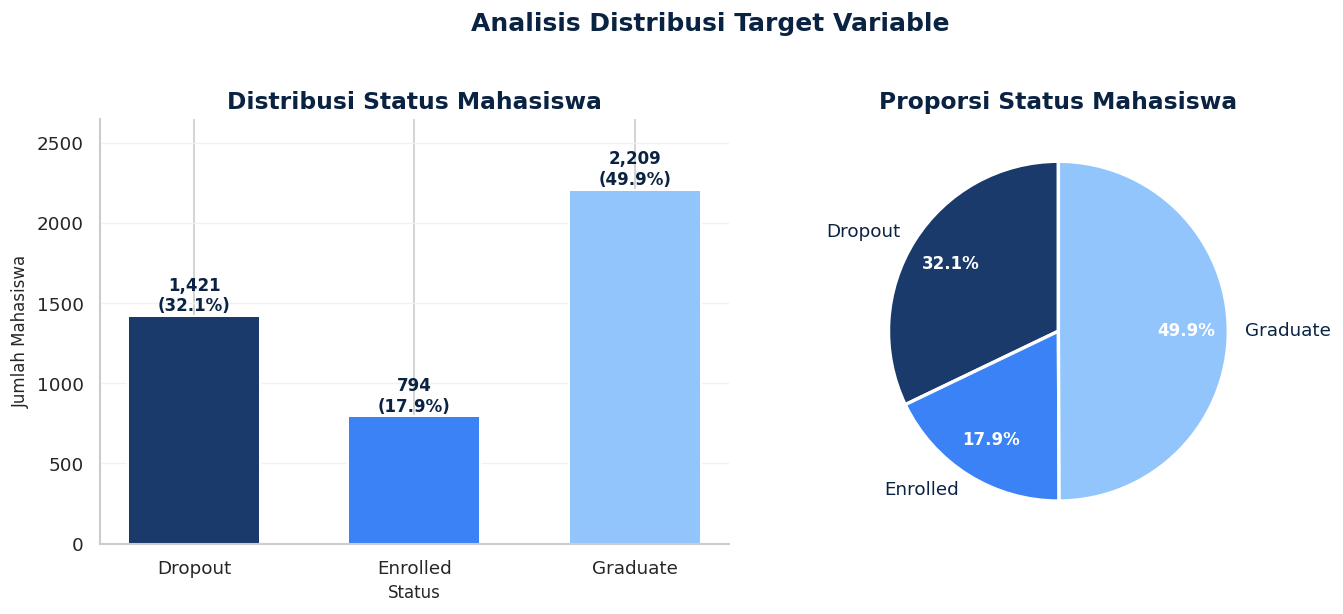

  Dropout     : 1,421 (32.1%)
  Enrolled    : 794 (17.9%)
  Graduate    : 2,209 (49.9%)


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
status_counts = df['Status'].value_counts().reindex(['Dropout', 'Enrolled', 'Graduate'])

# Warna gradasi biru
colors = ['#1a3a6b', '#3b82f6', '#93c5fd']

# Bar chart
axes[0].bar(status_counts.index, status_counts.values, color=colors,
            edgecolor='white', linewidth=1.2, width=0.6)
axes[0].set_title('Distribusi Status Mahasiswa', fontsize=14, fontweight='bold', color='#0a2342')
axes[0].set_xlabel('Status', fontsize=10)
axes[0].set_ylabel('Jumlah Mahasiswa', fontsize=10)
axes[0].spines[['top', 'right']].set_visible(False)
axes[0].yaxis.grid(True, color='#eef2f7', linewidth=0.8)
axes[0].set_axisbelow(True)
axes[0].set_ylim(0, status_counts.max() * 1.20)
for i, (idx, val) in enumerate(status_counts.items()):
    axes[0].text(i, val + 30, f'{val:,}\n({val/len(df)*100:.1f}%)',
                 ha='center', fontsize=10, fontweight='bold', color='#0a2342')

# Pie chart
wedges, texts, autotexts = axes[1].pie(
    status_counts.values,
    labels=status_counts.index,
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=2),
    pctdistance=0.75,
)
for at in autotexts:
    at.set_fontsize(10)
    at.set_fontweight('bold')
    at.set_color('white')
for t in texts:
    t.set_fontsize(11)
    t.set_color('#0a2342')
axes[1].set_title('Proporsi Status Mahasiswa', fontsize=14, fontweight='bold', color='#0a2342')

plt.suptitle('Analisis Distribusi Target Variable', fontsize=15,
             fontweight='bold', color='#0a2342', y=1.02)
plt.tight_layout()
plt.show()

for status, count in status_counts.items():
    print(f'  {status:<12}: {count:,} ({count/len(df)*100:.1f}%)')

Insight:
- Kelas Enrolled merupakan minoritas (~18%)
- SMOTE akan diterapkan pada training set untuk menyeimbangkan distribusi kelas

### 4. Analisis Faktor Demografis & Finansial

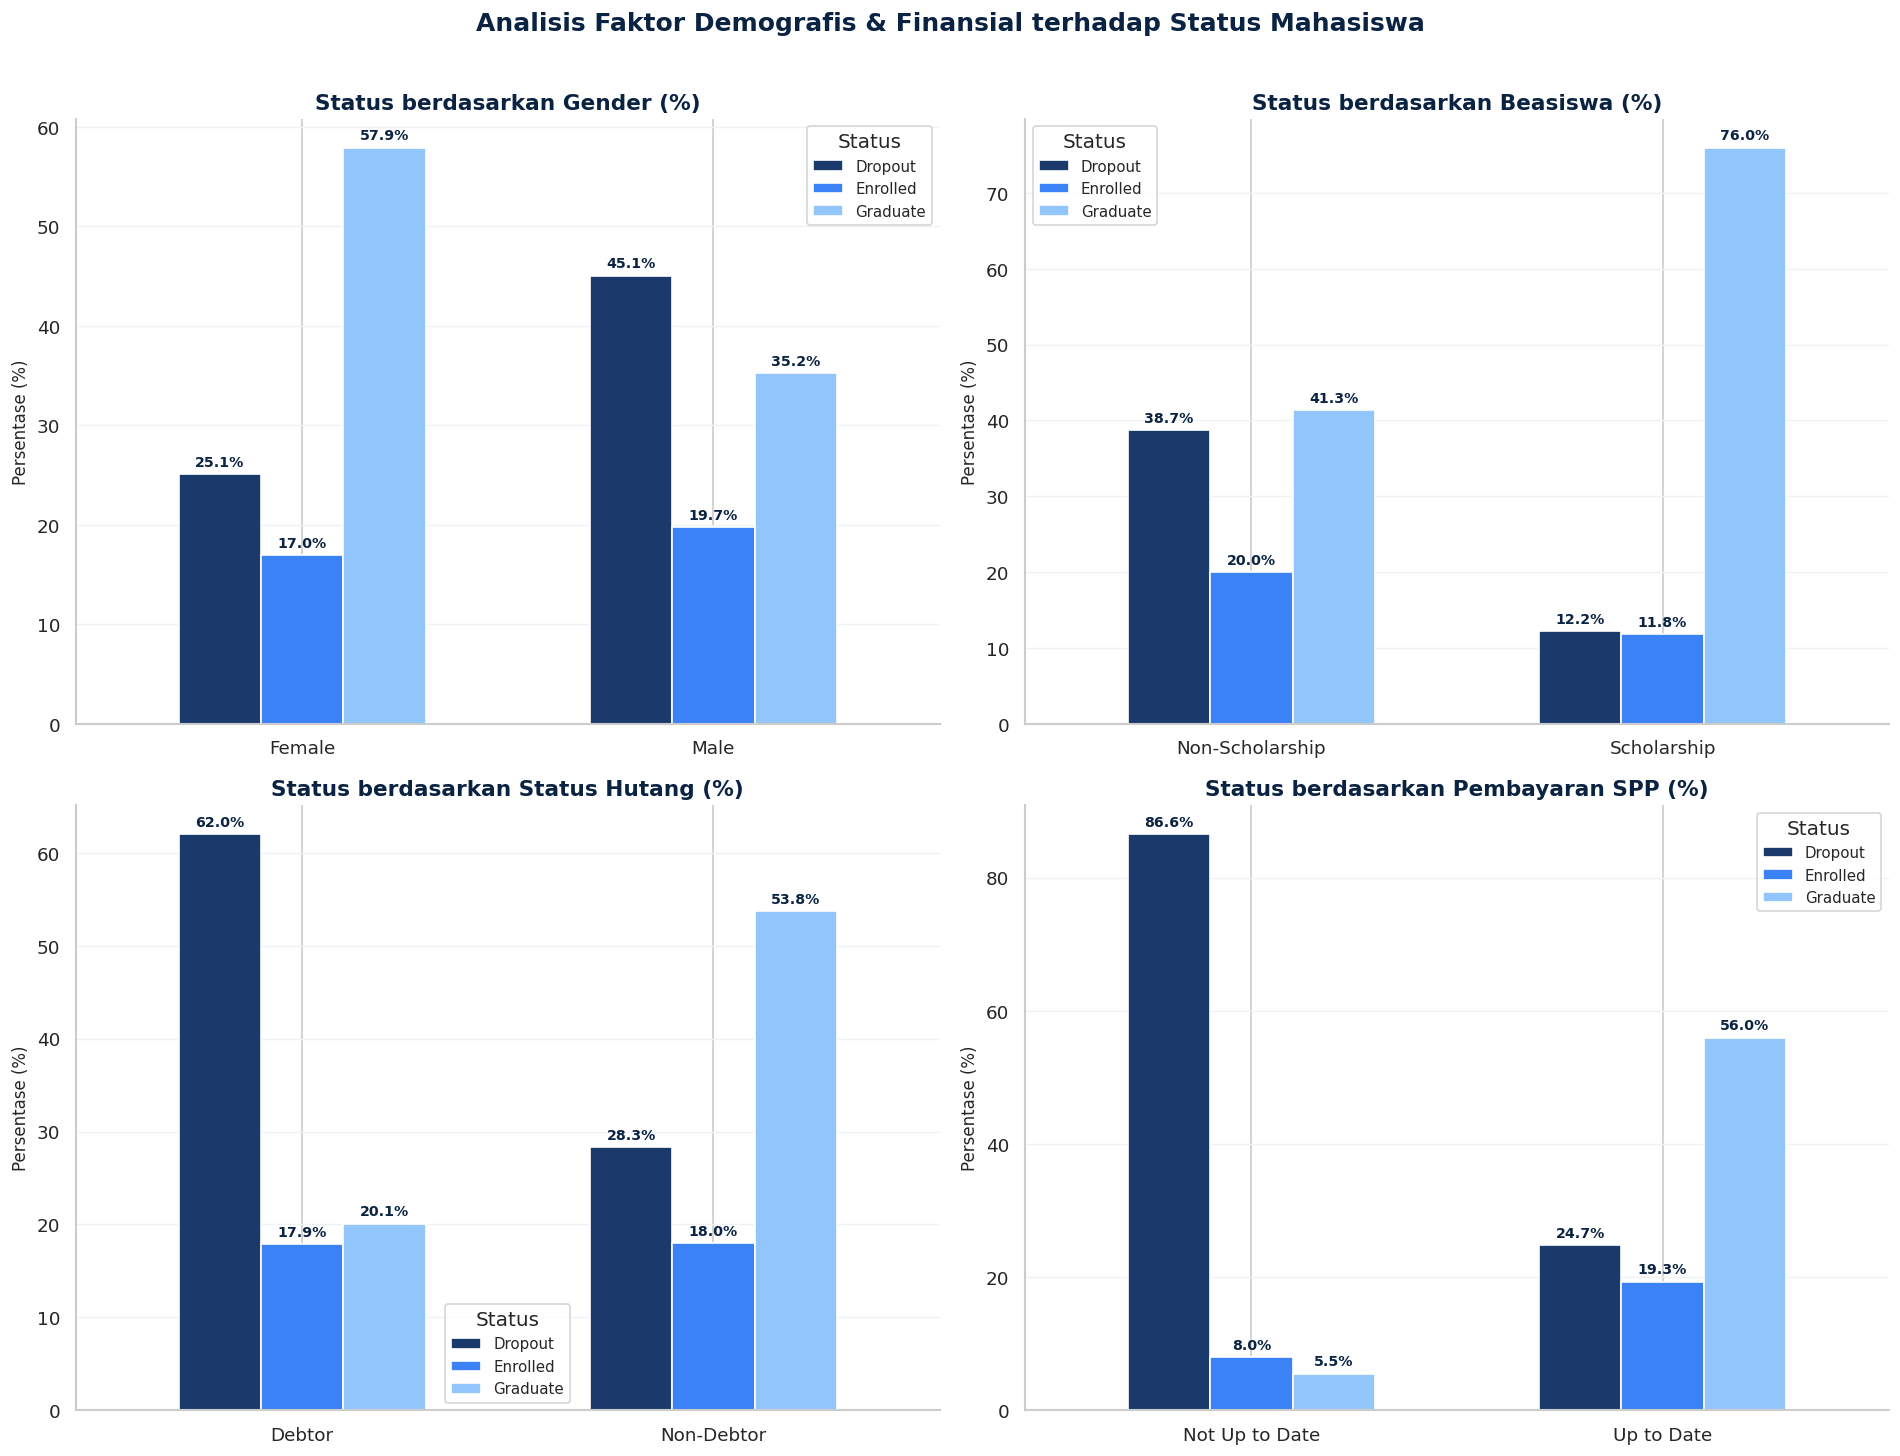

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Warna gradasi biru
status_palette = {
    'Dropout':  '#1a3a6b',
    'Enrolled': '#3b82f6',
    'Graduate': '#93c5fd',
}
order = ['Dropout', 'Enrolled', 'Graduate']

def plot_pct_bar(ax, col_label, title):
    ct = pd.crosstab(df[col_label], df['Status'], normalize='index') * 100
    ct = ct.reindex(columns=order, fill_value=0)
    bar_colors = [status_palette[s] for s in order]
    ct.plot(kind='bar', ax=ax, color=bar_colors, edgecolor='white', width=0.6)
    ax.set_title(title, fontsize=13, fontweight='bold', color='#0a2342')
    ax.set_xlabel(''); ax.set_ylabel('Persentase (%)', fontsize=10)
    ax.tick_params(axis='x', rotation=0)
    ax.legend(title='Status', fontsize=9)
    ax.spines[['top', 'right']].set_visible(False)
    ax.yaxis.grid(True, color='#eef2f7', linewidth=0.8)
    ax.set_axisbelow(True)
    # Tambahkan label nilai di atas setiap bar
    for container in ax.containers:
        ax.bar_label(container, fmt='%.1f%%', fontsize=8.5,
                     fontweight='600', padding=3, color='#0a2342')

# Gender vs Status
df['Gender_label'] = df['Gender'].map({1: 'Male', 0: 'Female'})
plot_pct_bar(axes[0,0], 'Gender_label', 'Status berdasarkan Gender (%)')

# Scholarship vs Status
df['Scholar_label'] = df['Scholarship_holder'].map({1: 'Scholarship', 0: 'Non-Scholarship'})
plot_pct_bar(axes[0,1], 'Scholar_label', 'Status berdasarkan Beasiswa (%)')

# Debtor vs Status
df['Debtor_label'] = df['Debtor'].map({1: 'Debtor', 0: 'Non-Debtor'})
plot_pct_bar(axes[1,0], 'Debtor_label', 'Status berdasarkan Status Hutang (%)')

# Tuition vs Status
df['Tuition_label'] = df['Tuition_fees_up_to_date'].map({1: 'Up to Date', 0: 'Not Up to Date'})
plot_pct_bar(axes[1,1], 'Tuition_label', 'Status berdasarkan Pembayaran SPP (%)')

plt.suptitle('Analisis Faktor Demografis & Finansial terhadap Status Mahasiswa',
             fontsize=15, fontweight='bold', color='#0a2342', y=1.01)
plt.tight_layout()
plt.show()

df.drop(columns=['Gender_label','Scholar_label','Debtor_label','Tuition_label'], inplace=True)

Insight:
- Mahasiswa yang tidak membayar SPP tepat waktu memiliki dropout rate sangat tinggi (86.6%), sedangkan yang membayar tepat waktu didominasi oleh status graduate (56.0%).
- Penerima beasiswa memiliki tingkat kelulusan jauh lebih tinggi (76.0%) dibandingkan non-penerima (41.3%), serta dropout rate yang jauh lebih rendah (12.2% vs 38.7%).
- Mahasiswa dengan status hutang (debtor) menunjukkan dropout rate lebih tinggi (62.0%) dibandingkan non-debtor (28.3%), sementara non-debtor lebih banyak yang lulus (53.8%).

### 5. Distribusi Nilai Akademik

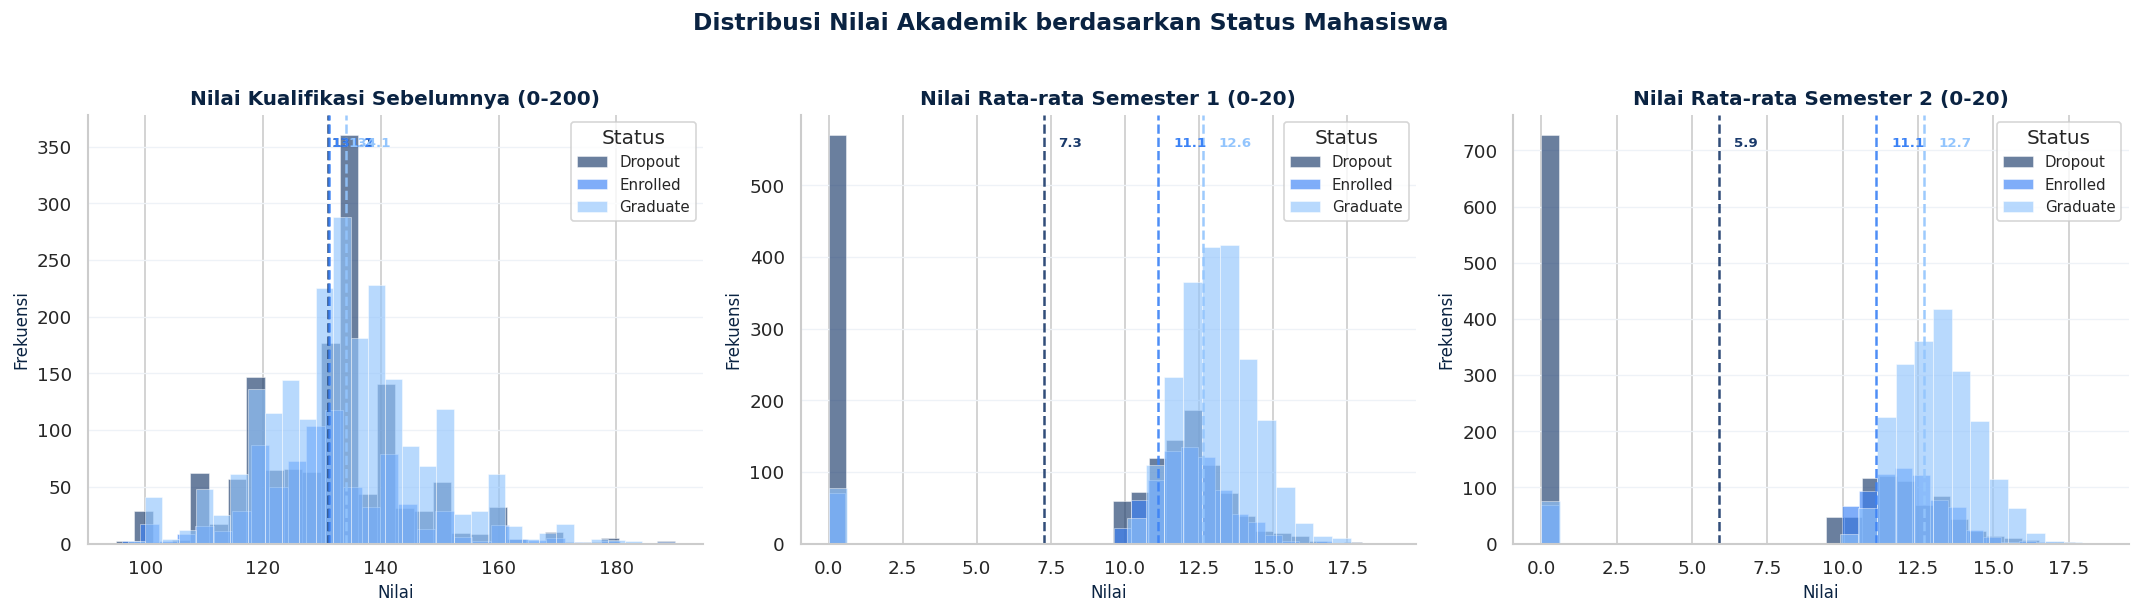

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Warna gradasi biru
status_palette = {
    'Dropout':  '#1a3a6b',
    'Enrolled': '#3b82f6',
    'Graduate': '#93c5fd',
}
order = ['Dropout', 'Enrolled', 'Graduate']

grade_cols = [
    ('Previous_qualification_grade', 'Nilai Kualifikasi Sebelumnya (0-200)'),
    ('Curricular_units_1st_sem_grade', 'Nilai Rata-rata Semester 1 (0-20)'),
    ('Curricular_units_2nd_sem_grade', 'Nilai Rata-rata Semester 2 (0-20)'),
]

for ax, (col, title) in zip(axes, grade_cols):
    for status in order:
        grp = df[df['Status'] == status]
        ax.hist(grp[col], bins=30, alpha=0.65, label=status,
                color=status_palette[status], edgecolor='white', linewidth=0.4)

    # Tambahkan garis mean per status
    for status in order:
        grp = df[df['Status'] == status]
        mean_val = grp[col].mean()
        ax.axvline(mean_val, color=status_palette[status],
                   linestyle='--', linewidth=1.5, alpha=0.9)
        ax.text(mean_val + 0.5, ax.get_ylim()[1] * 0.95,
                f'{mean_val:.1f}', fontsize=8, color=status_palette[status],
                fontweight='bold', va='top')

    ax.set_title(title, fontsize=12, fontweight='bold', color='#0a2342')
    ax.set_xlabel('Nilai', fontsize=10, color='#0a2342')
    ax.set_ylabel('Frekuensi', fontsize=10, color='#0a2342')
    ax.spines[['top', 'right']].set_visible(False)
    ax.yaxis.grid(True, color='#eef2f7', linewidth=0.8)
    ax.set_axisbelow(True)
    ax.legend(title='Status', fontsize=9)

plt.suptitle('Distribusi Nilai Akademik berdasarkan Status Mahasiswa',
             fontsize=14, fontweight='bold', color='#0a2342', y=1.02)
plt.tight_layout()
plt.show()

Insight:
- Mahasiswa dropout memiliki distribusi nilai Semester 1 (~7.3) dan Semester 2 (~5.9) yang jauh lebih rendah, dengan banyak nilai yang sangat rendah (mendekati 0).
- Mahasiswa graduate memiliki nilai yang lebih tinggi dan konsisten, dengan rata-rata sekitar 12.6 (Semester 1) dan 12.7 (Semester 2).

### 6. Analisis Unit Kurikuler

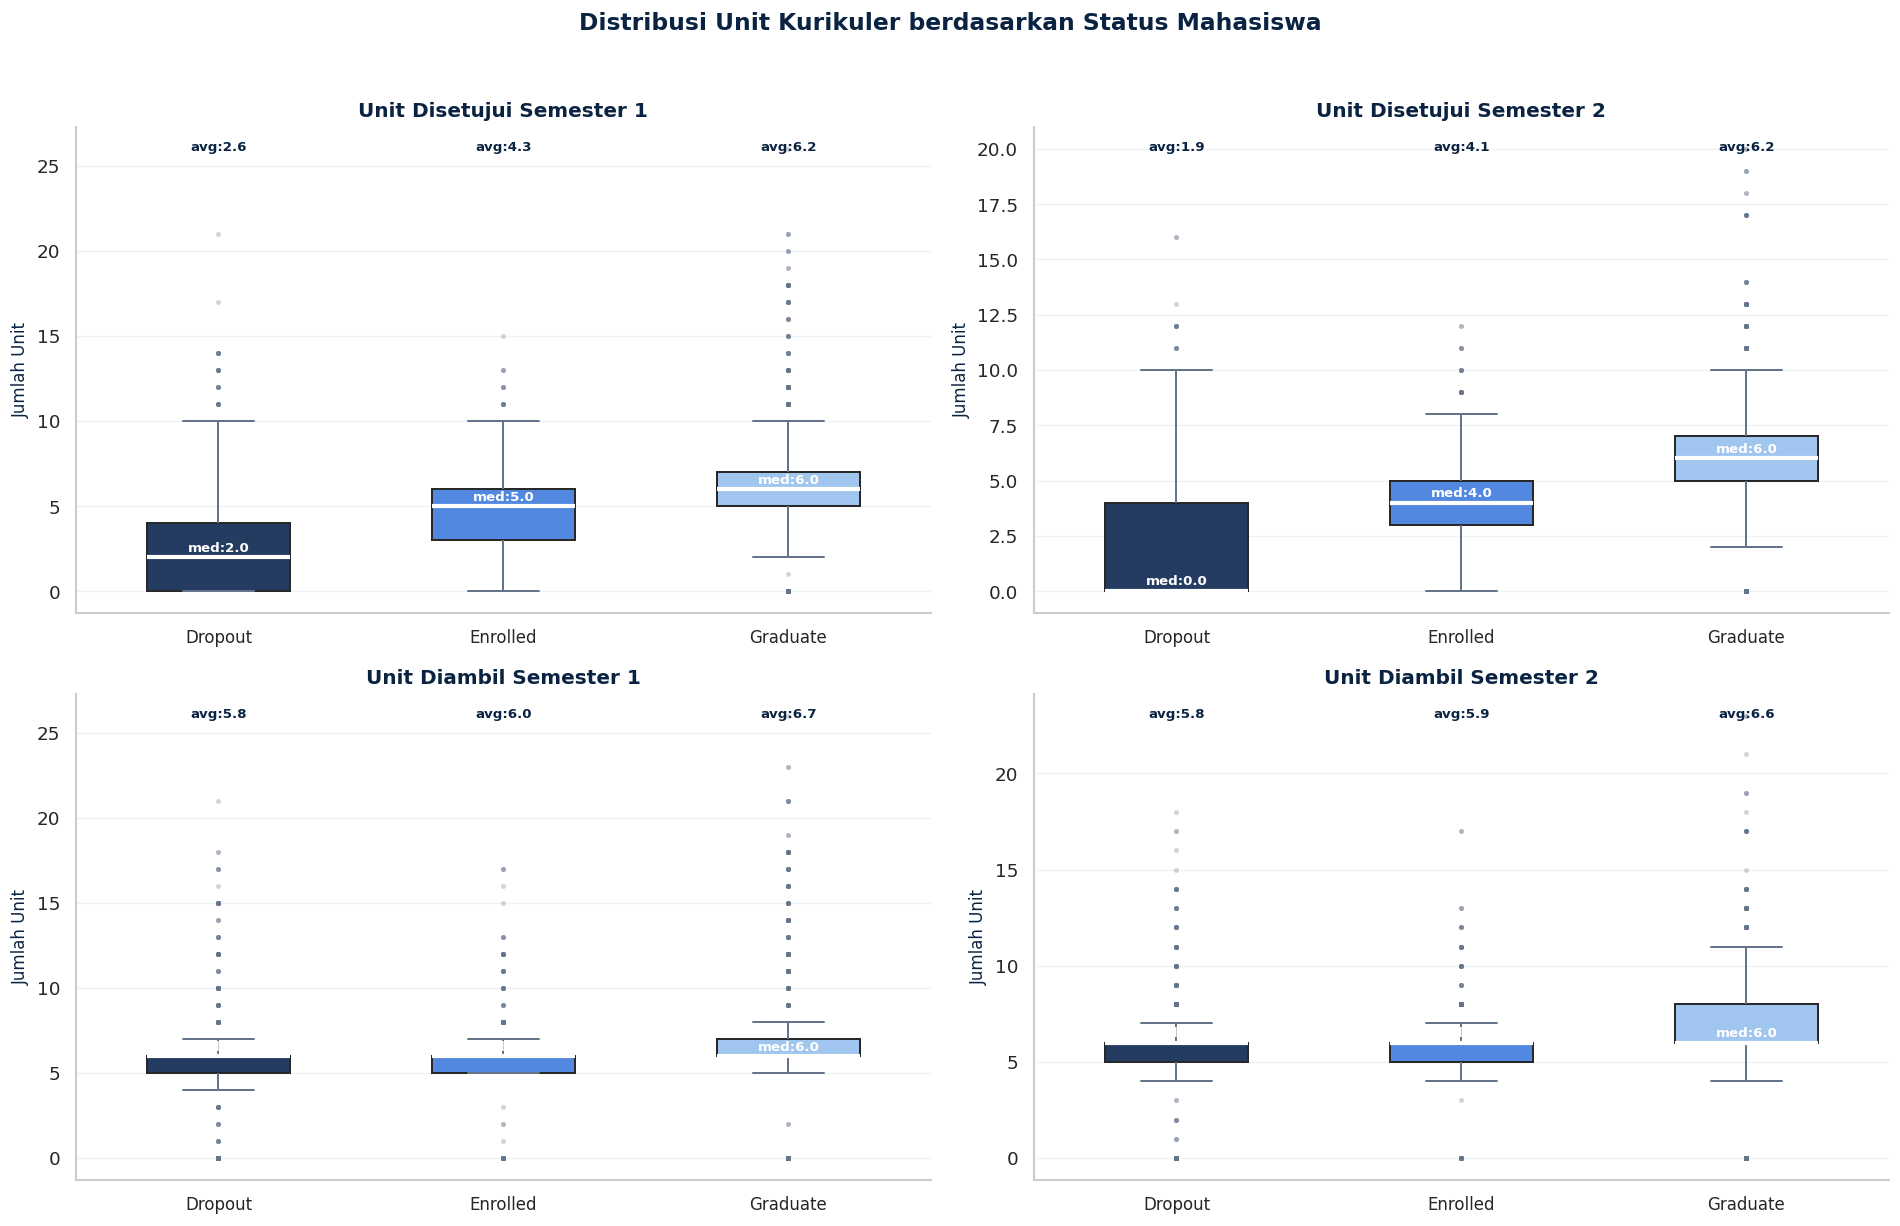

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Warna gradasi biru
status_palette = {
    'Dropout':  '#1a3a6b',
    'Enrolled': '#3b82f6',
    'Graduate': '#93c5fd',
}
order = ['Dropout', 'Enrolled', 'Graduate']

box_cols = [
    ('Curricular_units_1st_sem_approved', 'Unit Disetujui Semester 1', axes[0,0]),
    ('Curricular_units_2nd_sem_approved', 'Unit Disetujui Semester 2', axes[0,1]),
    ('Curricular_units_1st_sem_enrolled', 'Unit Diambil Semester 1',   axes[1,0]),
    ('Curricular_units_2nd_sem_enrolled', 'Unit Diambil Semester 2',   axes[1,1]),
]

for col, title, ax in box_cols:
    sns.boxplot(
        data=df, x='Status', y=col, order=order,
        palette=status_palette, ax=ax,
        width=0.5, linewidth=1.2,
        medianprops=dict(color='white', linewidth=2.5),
        whiskerprops=dict(color='#64748b'),
        capprops=dict(color='#64748b'),
        flierprops=dict(marker='o', markersize=3, alpha=0.3,
                        markerfacecolor='#64748b', markeredgecolor='none'),
    )

    # Tambahkan label median & mean di atas setiap box
    for i, status in enumerate(order):
        grp = df[df['Status'] == status][col].dropna()
        median_val = grp.median()
        mean_val   = grp.mean()
        ax.text(i, median_val + 0.15, f'med:{median_val:.1f}',
                ha='center', va='bottom', fontsize=8,
                fontweight='bold', color='white')
        ax.text(i, ax.get_ylim()[1] * 0.97, f'avg:{mean_val:.1f}',
                ha='center', va='top', fontsize=8,
                color='#0a2342', fontweight='600')

    ax.set_title(title, fontsize=12, fontweight='bold', color='#0a2342')
    ax.set_xlabel('', fontsize=10)
    ax.set_ylabel('Jumlah Unit', fontsize=10, color='#0a2342')
    ax.spines[['top', 'right']].set_visible(False)
    ax.yaxis.grid(True, color='#eef2f7', linewidth=0.8)
    ax.set_axisbelow(True)
    ax.tick_params(axis='x', labelsize=10)

plt.suptitle('Distribusi Unit Kurikuler berdasarkan Status Mahasiswa',
             fontsize=14, fontweight='bold', color='#0a2342', y=1.02)
plt.tight_layout()
plt.show()

Insight:
- Mahasiswa dropout memiliki jumlah unit disetujui yang sangat rendah, terutama pada Semester 2 (median ≈ 0), jauh di bawah enrolled (≈ 4) dan graduate (≈ 6).
- Jumlah unit yang disetujui menunjukkan pemisahan yang sangat jelas antar status mahasiswa, di mana graduate konsisten memiliki nilai tertinggi, diikuti enrolled, dan dropout paling rendah.

### 7. Correlation Heatmap

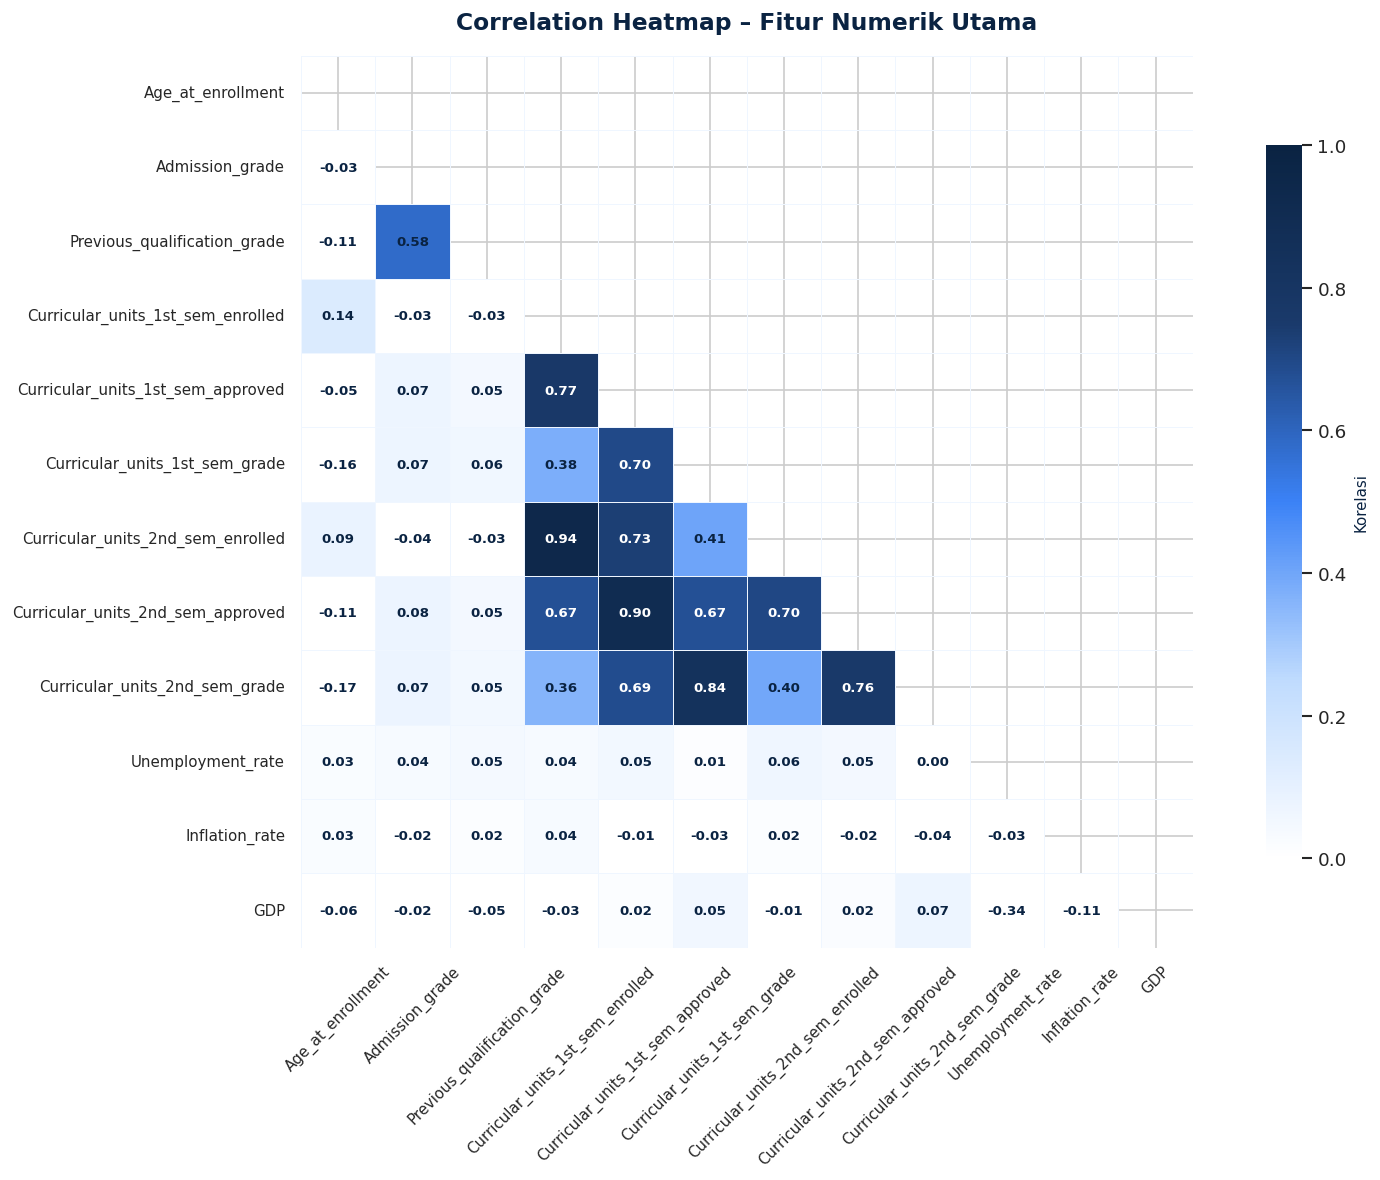

In [11]:
corr_cols = [
    'Age_at_enrollment','Admission_grade','Previous_qualification_grade',
    'Curricular_units_1st_sem_enrolled','Curricular_units_1st_sem_approved',
    'Curricular_units_1st_sem_grade','Curricular_units_2nd_sem_enrolled',
    'Curricular_units_2nd_sem_approved','Curricular_units_2nd_sem_grade',
    'Unemployment_rate','Inflation_rate','GDP'
]
corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Colormap gradasi biru
from matplotlib.colors import LinearSegmentedColormap
blue_cmap = LinearSegmentedColormap.from_list(
    'blue_corr',
    ['#ffffff', '#bfdbfe', '#3b82f6', '#1a3a6b', '#0a2342']
)

sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap=blue_cmap, vmin=0, vmax=1,
    square=True, linewidths=0.5, linecolor='#eff6ff',
    ax=ax, annot_kws={'size': 8, 'color': '#0a2342', 'fontweight': '600'},
    cbar_kws={'shrink': 0.8, 'label': 'Korelasi'}
)

# Warnai teks sel
for text in ax.texts:
    try:
        val = float(text.get_text())
        if val > 0.6:
            text.set_color('white')
        else:
            text.set_color('#0a2342')
    except ValueError:
        pass

ax.set_title('Correlation Heatmap – Fitur Numerik Utama',
             fontsize=14, fontweight='bold', color='#0a2342', pad=16)
ax.tick_params(axis='x', rotation=45, labelsize=9)
ax.tick_params(axis='y', rotation=0,  labelsize=9)
ax.figure.axes[-1].set_ylabel('Korelasi', fontsize=9, color='#0a2342')

plt.tight_layout()
plt.show()

Insight:
- Nilai Semester 1 dan Semester 2 memiliki korelasi positif kuat (≈ 0.84), menunjukkan konsistensi performa akademik antar semester.
- Jumlah unit yang disetujui memiliki korelasi positif kuat dengan nilai rata-rata (≈ 0.67–0.84), menandakan bahwa semakin banyak unit yang disetujui, semakin tinggi nilai akademik mahasiswa.

### 8. Distribusi Usia dan Faktor Ekonomi Makro

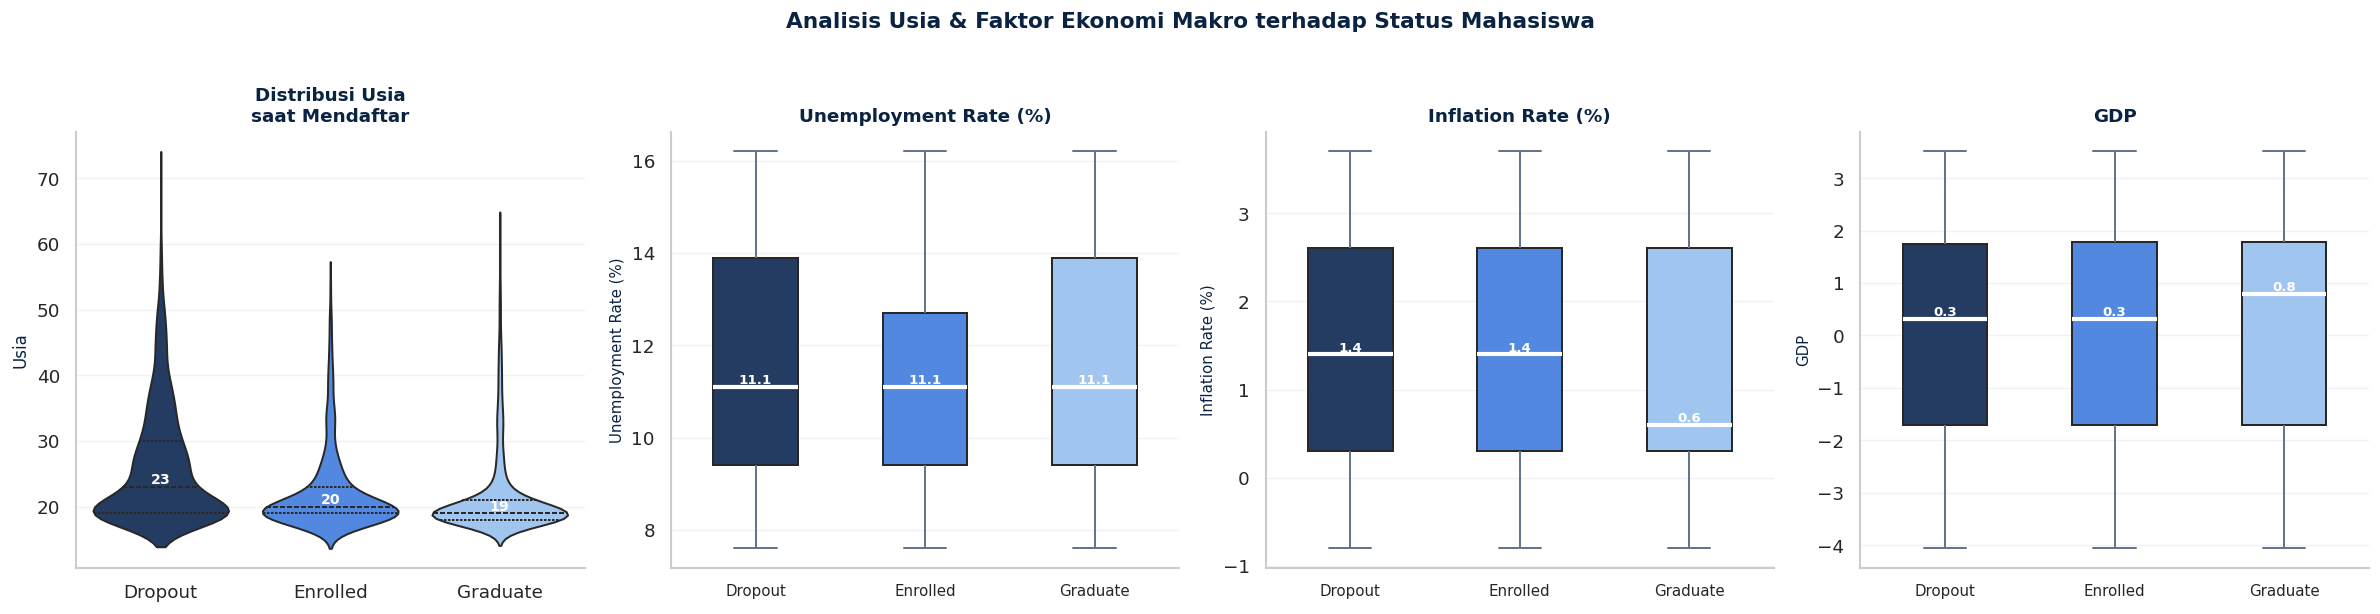

In [12]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

# Warna gradasi biru
status_palette = {
    'Dropout':  '#1a3a6b',
    'Enrolled': '#3b82f6',
    'Graduate': '#93c5fd',
}
order = ['Dropout', 'Enrolled', 'Graduate']

# Violin plot – Usia
sns.violinplot(
    data=df, x='Status', y='Age_at_enrollment', order=order,
    palette=status_palette, ax=axes[0], inner='quartile',
    linewidth=1.2,
)
# Label median usia per status
for i, status in enumerate(order):
    med = df[df['Status'] == status]['Age_at_enrollment'].median()
    axes[0].text(i, med + 0.5, f'{med:.0f}',
                 ha='center', fontsize=8.5, fontweight='bold', color='white')
axes[0].set_title('Distribusi Usia\nsaat Mendaftar', fontsize=11,
                  fontweight='bold', color='#0a2342')
axes[0].set_xlabel('')
axes[0].set_ylabel('Usia', fontsize=10, color='#0a2342')
axes[0].spines[['top', 'right']].set_visible(False)
axes[0].yaxis.grid(True, color='#eef2f7', linewidth=0.8)
axes[0].set_axisbelow(True)

# Boxplot – Faktor Ekonomi Makro
for ax, col, title in zip(axes[1:],
    ['Unemployment_rate', 'Inflation_rate', 'GDP'],
    ['Unemployment Rate (%)', 'Inflation Rate (%)', 'GDP']):

    sns.boxplot(
        data=df, x='Status', y=col, order=order,
        palette=status_palette, ax=ax,
        width=0.5, linewidth=1.2,
        medianprops=dict(color='white', linewidth=2.5),
        whiskerprops=dict(color='#64748b'),
        capprops=dict(color='#64748b'),
        flierprops=dict(marker='o', markersize=3, alpha=0.3,
                        markerfacecolor='#64748b', markeredgecolor='none'),
    )

    # Label median per status
    for i, status in enumerate(order):
        med = df[df['Status'] == status][col].median()
        ax.text(i, med, f'{med:.1f}',
                ha='center', va='bottom', fontsize=8,
                fontweight='bold', color='white')

    ax.set_title(title, fontsize=11, fontweight='bold', color='#0a2342')
    ax.set_xlabel('')
    ax.set_ylabel(title, fontsize=9, color='#0a2342')
    ax.spines[['top', 'right']].set_visible(False)
    ax.yaxis.grid(True, color='#eef2f7', linewidth=0.8)
    ax.set_axisbelow(True)
    ax.tick_params(axis='x', labelsize=9)

plt.suptitle('Analisis Usia & Faktor Ekonomi Makro terhadap Status Mahasiswa',
             fontsize=13, fontweight='bold', color='#0a2342', y=1.02)
plt.tight_layout()
plt.show()

Insight:
- Mahasiswa dropout cenderung memiliki usia saat mendaftar yang sedikit lebih tinggi (median ≈ 23) dibandingkan enrolled (≈ 20) dan graduate (≈ 19).
- Faktor ekonomi makro seperti unemployment rate, inflation rate, dan GDP tidak menunjukkan perbedaan yang signifikan antar status mahasiswa, sehingga pengaruhnya terhadap dropout relatif lemah.

---
## Data Preparation / Preprocessing

Tahap ini mencakup encoding target, feature engineering, train-test split, dan penanganan class imbalance menggunakan **SMOTE** pada data training.

### 1. Encoding Target Variable

In [13]:
le = LabelEncoder()
df['Status_encoded'] = le.fit_transform(df['Status'])
label_mapping = {i: cls for i, cls in enumerate(le.classes_)}

print('Label Encoding Target:')
for cls, idx in zip(le.classes_, range(len(le.classes_))):
    print(f'  {cls} -> {idx}')
print('\nMapping:', label_mapping)

Label Encoding Target:
  Dropout -> 0
  Enrolled -> 1
  Graduate -> 2

Mapping: {0: 'Dropout', 1: 'Enrolled', 2: 'Graduate'}


### 2. Feature Engineering

Kita akan membuat beberapa fitur turunan yang dapat menangkap pola akademik lebih baik dari fitur mentah.

In [14]:
df_feat = df.copy()

# Rasio kelulusan unit per semester (efisiensi akademik)
df_feat['approval_rate_sem1'] = (
    df_feat['Curricular_units_1st_sem_approved'] /
    df_feat['Curricular_units_1st_sem_enrolled'].replace(0, np.nan)
).fillna(0)

df_feat['approval_rate_sem2'] = (
    df_feat['Curricular_units_2nd_sem_approved'] /
    df_feat['Curricular_units_2nd_sem_enrolled'].replace(0, np.nan)
).fillna(0)

# Total unit disetujui kedua semester
df_feat['total_approved'] = (
    df_feat['Curricular_units_1st_sem_approved'] +
    df_feat['Curricular_units_2nd_sem_approved']
)

# Nilai rata-rata gabungan kedua semester
df_feat['avg_grade_both_sem'] = (
    df_feat['Curricular_units_1st_sem_grade'] +
    df_feat['Curricular_units_2nd_sem_grade']
) / 2

# Flag mahasiswa aktif secara akademik
df_feat['is_academically_active'] = (
    (df_feat['Curricular_units_1st_sem_evaluations'] > 0) |
    (df_feat['Curricular_units_2nd_sem_evaluations'] > 0)
).astype(int)

# Tren nilai antar semester (positif = membaik, negatif = memburuk)
df_feat['grade_trend'] = (
    df_feat['Curricular_units_2nd_sem_grade'] -
    df_feat['Curricular_units_1st_sem_grade']
)

new_features = ['approval_rate_sem1','approval_rate_sem2','total_approved',
                'avg_grade_both_sem','is_academically_active','grade_trend']

print(f'Fitur baru ditambahkan ({len(new_features)}):')
for f in new_features:
    print(f'  * {f}')

Fitur baru ditambahkan (6):
  * approval_rate_sem1
  * approval_rate_sem2
  * total_approved
  * avg_grade_both_sem
  * is_academically_active
  * grade_trend


### 3. Feature Selection

In [15]:
drop_cols = ['Status', 'Status_encoded']
feature_cols = [col for col in df_feat.columns if col not in drop_cols]

X = df_feat[feature_cols].copy()
y = df_feat['Status_encoded'].copy()

print(f'Total fitur   : {X.shape[1]}')
print(f'Total sampel  : {X.shape[0]:,}')

Total fitur   : 42
Total sampel  : 4,424


### 4. Train-Test Split

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f'Training set  : {X_train.shape[0]:,} sampel ({X_train.shape[0]/len(X)*100:.1f}%)')
print(f'Testing set   : {X_test.shape[0]:,} sampel ({X_test.shape[0]/len(X)*100:.1f}%)')

print('\nDistribusi kelas training set (SEBELUM SMOTE):')
for cls, cnt in sorted(pd.Series(y_train).value_counts().items()):
    print(f'  {label_mapping[cls]:<12}: {cnt:,} ({cnt/len(y_train)*100:.1f}%)')

Training set  : 3,539 sampel (80.0%)
Testing set   : 885 sampel (20.0%)

Distribusi kelas training set (SEBELUM SMOTE):
  Dropout     : 1,137 (32.1%)
  Enrolled    : 635 (17.9%)
  Graduate    : 1,767 (49.9%)


### 5. Penanganan Class Imbalance dengan SMOTE

**SMOTE (Synthetic Minority Over-sampling Technique)** digunakan untuk mensintesis sampel baru pada kelas minoritas (Enrolled ~18%) melalui interpolasi k-Nearest Neighbors. SMOTE **hanya diterapkan pada data training** untuk menghindari data leakage pada evaluasi.

SMOTE berhasil diterapkan pada training set.
Ukuran training set setelah SMOTE : 5,301 (sebelumnya: 3,539)

Distribusi kelas training set (SESUDAH SMOTE):
  Dropout     : 1,767 (33.3%)
  Enrolled    : 1,767 (33.3%)
  Graduate    : 1,767 (33.3%)


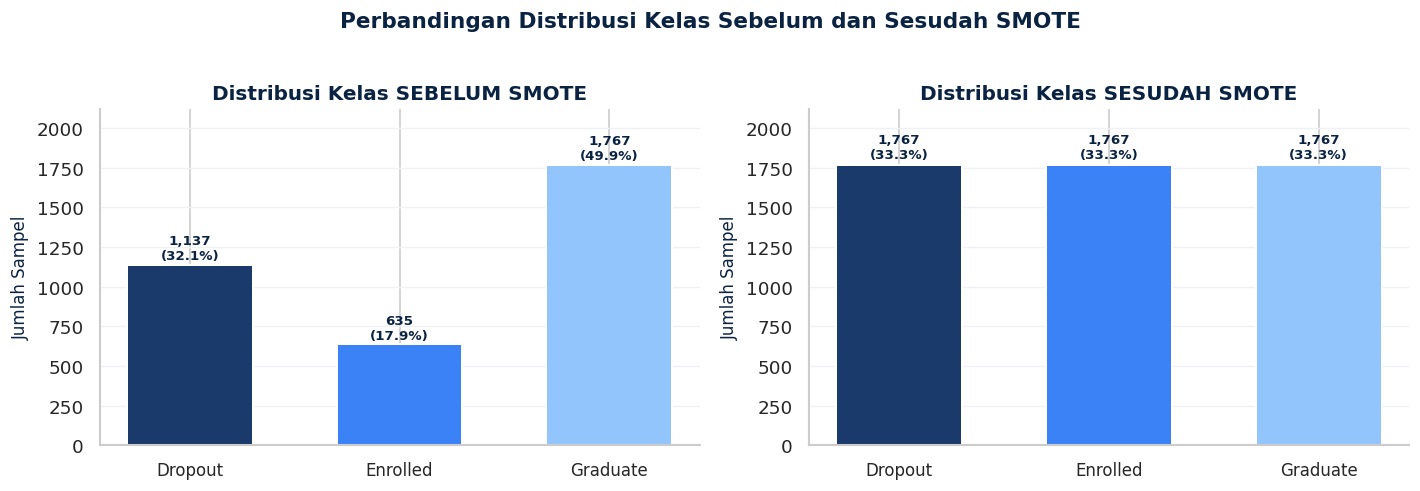


Catatan: Data testing tetap menggunakan distribusi asli untuk evaluasi yang realistis.


In [17]:
smote = SMOTE(random_state=RANDOM_STATE, k_neighbors=5)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print('SMOTE berhasil diterapkan pada training set.')
print(f'Ukuran training set setelah SMOTE : {X_train_smote.shape[0]:,} (sebelumnya: {X_train.shape[0]:,})')

print('\nDistribusi kelas training set (SESUDAH SMOTE):')
for cls, cnt in sorted(pd.Series(y_train_smote).value_counts().items()):
    print(f'  {label_mapping[cls]:<12}: {cnt:,} ({cnt/len(y_train_smote)*100:.1f}%)')

# Visualisasi sebelum vs sesudah
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

before_counts = pd.Series(y_train).map(label_mapping).value_counts().reindex(order, fill_value=0)
after_counts  = pd.Series(y_train_smote).map(label_mapping).value_counts().reindex(order, fill_value=0)

# Warna gradasi biru
status_palette = {
    'Dropout':  '#1a3a6b',
    'Enrolled': '#3b82f6',
    'Graduate': '#93c5fd',
}
bar_colors = [status_palette[s] for s in order]

for ax, counts, title in zip(
    axes,
    [before_counts, after_counts],
    ['Distribusi Kelas SEBELUM SMOTE', 'Distribusi Kelas SESUDAH SMOTE']
):
    bars = ax.bar(counts.index, counts.values, color=bar_colors,
                  edgecolor='white', linewidth=1.2, width=0.6)
    ax.set_title(title, fontsize=12, fontweight='bold', color='#0a2342')
    ax.set_ylabel('Jumlah Sampel', fontsize=10, color='#0a2342')
    ax.set_ylim(0, counts.max() * 1.20)   # ← tambahkan ini
    ax.spines[['top', 'right']].set_visible(False)
    ax.yaxis.grid(True, color='#eef2f7', linewidth=0.8)
    ax.set_axisbelow(True)
    ax.tick_params(axis='x', labelsize=10)
    total = counts.sum()
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width() / 2,
                val + total * 0.005,
                f'{val:,}\n({val/total*100:.1f}%)',
                ha='center', va='bottom',
                fontsize=8, fontweight='bold', color='#0a2342')

plt.suptitle('Perbandingan Distribusi Kelas Sebelum dan Sesudah SMOTE',
             fontsize=13, fontweight='bold', color='#0a2342', y=1.02)
plt.tight_layout()
plt.show()

print('\nCatatan: Data testing tetap menggunakan distribusi asli untuk evaluasi yang realistis.')

---
## Modeling

Digunakan dua model: **Random Forest** dan **XGBoost**, masing-masing dengan **RandomizedSearchCV** untuk menemukan kombinasi hyperparameter terbaik.

### 1. Hyperparameter Tuning – Random Forest

In [18]:
print('Melakukan RandomizedSearchCV untuk Random Forest...')

rf_param_dist = {
    'n_estimators'     : [200, 300, 400, 500],
    'max_depth'        : [10, 15, 20, 30, None],
    'min_samples_split': [2, 5, 10, 15],
    'min_samples_leaf' : [1, 2, 4, 8],
    'max_features'     : ['sqrt', 'log2', 0.3, 0.5, 0.7],
    'bootstrap'        : [True, False],
}

cv_strat = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

rf_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
    rf_param_dist,
    n_iter=50, scoring='f1_weighted', cv=cv_strat,
    n_jobs=-1, random_state=RANDOM_STATE, verbose=1
)
rf_search.fit(X_train_smote, y_train_smote)

best_rf = rf_search.best_estimator_
print(f'\nBest CV F1-Score (RF): {rf_search.best_score_:.4f}')
print('Best Parameters RF:')
for k, v in rf_search.best_params_.items():
    print(f'  {k}: {v}')

Melakukan RandomizedSearchCV untuk Random Forest...
Fitting 5 folds for each of 50 candidates, totalling 250 fits

Best CV F1-Score (RF): 0.8388
Best Parameters RF:
  n_estimators: 200
  min_samples_split: 2
  min_samples_leaf: 2
  max_features: sqrt
  max_depth: 30
  bootstrap: False


### 2. Hyperparameter Tuning – XGBoost

In [19]:
print('Melakukan RandomizedSearchCV untuk XGBoost...')

xgb_param_dist = {
    'n_estimators'    : [200, 250, 300, 350, 400],
    'max_depth'       : [4, 5, 6, 7, 8],
    'learning_rate'   : [0.05, 0.08, 0.1, 0.12, 0.15],
    'subsample'       : [0.7, 0.75, 0.8, 0.85, 0.9],
    'colsample_bytree': [0.7, 0.75, 0.8, 0.85, 0.9],
    'min_child_weight': [1, 3, 5],
    'gamma'           : [0, 0.1, 0.2],
    'reg_alpha'       : [0, 0.1, 0.5],
    'reg_lambda'      : [0.5, 1.0, 1.5],
}

xgb_search = RandomizedSearchCV(
    XGBClassifier(eval_metric='mlogloss', use_label_encoder=False,
                  random_state=RANDOM_STATE, n_jobs=-1),
    xgb_param_dist,
    n_iter=50, scoring='f1_weighted', cv=cv_strat,
    n_jobs=-1, random_state=RANDOM_STATE, verbose=1
)
xgb_search.fit(X_train_smote, y_train_smote)

best_xgb = xgb_search.best_estimator_
print(f'\nBest CV F1-Score (XGB): {xgb_search.best_score_:.4f}')
print('Best Parameters XGB:')
for k, v in xgb_search.best_params_.items():
    print(f'  {k}: {v}')

Melakukan RandomizedSearchCV untuk XGBoost...
Fitting 5 folds for each of 50 candidates, totalling 250 fits

Best CV F1-Score (XGB): 0.8596
Best Parameters XGB:
  subsample: 0.75
  reg_lambda: 1.0
  reg_alpha: 0.1
  n_estimators: 400
  min_child_weight: 1
  max_depth: 6
  learning_rate: 0.12
  gamma: 0
  colsample_bytree: 0.9


### 3. Prediksi pada Test Set

In [20]:
results = {}
for name, model in [('Random Forest', best_rf), ('XGBoost', best_xgb)]:
    y_pred = model.predict(X_test)
    results[name] = {
        'Accuracy' : accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, average='weighted', zero_division=0),
        'Recall'   : recall_score(y_test, y_pred, average='weighted'),
        'F1-Score' : f1_score(y_test, y_pred, average='weighted'),
        'model'    : model,
        'y_pred'   : y_pred,
    }
    print(f'{name}: Accuracy={results[name]["Accuracy"]:.4f} | F1={results[name]["F1-Score"]:.4f}')

Random Forest: Accuracy=0.7582 | F1=0.7588
XGBoost: Accuracy=0.7627 | F1=0.7608


---
## Evaluation

Evaluasi terhadap kedua model untuk memilih model terbaik.

### 1. Perbandingan Performa Model

=== PERBANDINGAN PERFORMA MODEL ===


,Accuracy,Precision,Recall,F1-Score
Random Forest,0.758200,0.763300,0.758200,0.758800
XGBoost,0.762700,0.760200,0.762700,0.760800


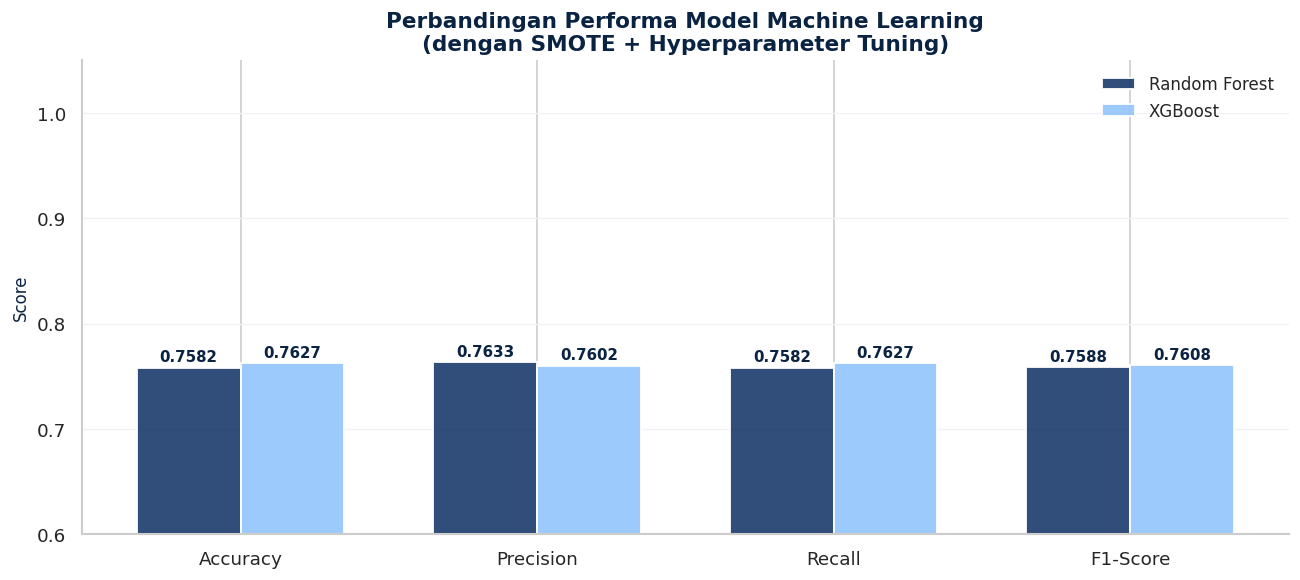

In [29]:
comparison_df = pd.DataFrame({
    name: {k: v for k, v in metrics.items() if k not in ['model','y_pred']}
    for name, metrics in results.items()
}).T.round(4)

print('=== PERBANDINGAN PERFORMA MODEL ===')
display(comparison_df.style.highlight_max(axis=0, color='#bfdbfe').highlight_min(axis=0, color='#eff6ff'))

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(comparison_df.columns))
width = 0.35

# Warna gradasi biru (konsisten dengan dashboard)
bar_colors = ['#1a3a6b', '#93c5fd']

for i, (model_name, row) in enumerate(comparison_df.iterrows()):
    bars = ax.bar(x + i*width, row.values, width, label=model_name,
                  color=bar_colors[i], alpha=0.90, edgecolor='white', linewidth=1.2)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                f'{bar.get_height():.4f}', ha='center', va='bottom',
                fontsize=9, fontweight='bold', color='#0a2342')

ax.set_title('Perbandingan Performa Model Machine Learning\n(dengan SMOTE + Hyperparameter Tuning)',
             fontsize=13, fontweight='bold', color='#0a2342')
ax.set_xticks(x + width/2)
ax.set_xticklabels(comparison_df.columns, fontsize=11)
ax.set_ylabel('Score', fontsize=10, color='#0a2342')
ax.set_ylim(0.6, 1.05)
ax.legend(fontsize=10, frameon=False)
ax.spines[['top', 'right']].set_visible(False)
ax.yaxis.grid(True, color='#eef2f7', linewidth=0.8)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

### 2. Pemilihan Model Terbaik

In [22]:
best_model_name = comparison_df['F1-Score'].idxmax()
best_model      = results[best_model_name]['model']
best_y_pred     = results[best_model_name]['y_pred']

print(f'Model terbaik berdasarkan F1-Score Weighted: {best_model_name}')
print(f'  Accuracy  : {results[best_model_name]["Accuracy"]:.4f}')
print(f'  F1-Score  : {results[best_model_name]["F1-Score"]:.4f}')
print(f'  Precision : {results[best_model_name]["Precision"]:.4f}')
print(f'  Recall    : {results[best_model_name]["Recall"]:.4f}')

Model terbaik berdasarkan F1-Score Weighted: XGBoost
  Accuracy  : 0.7627
  F1-Score  : 0.7608
  Precision : 0.7602
  Recall    : 0.7627


### 3. Classification Report

In [23]:
print(f'=== CLASSIFICATION REPORT: {best_model_name} ===')
print(classification_report(y_test, best_y_pred, target_names=le.classes_))

=== CLASSIFICATION REPORT: XGBoost ===
              precision    recall  f1-score   support

     Dropout       0.80      0.75      0.77       284
    Enrolled       0.49      0.48      0.49       159
    Graduate       0.83      0.88      0.85       442

    accuracy                           0.76       885
   macro avg       0.71      0.70      0.70       885
weighted avg       0.76      0.76      0.76       885



### 4. Confusion Matrix

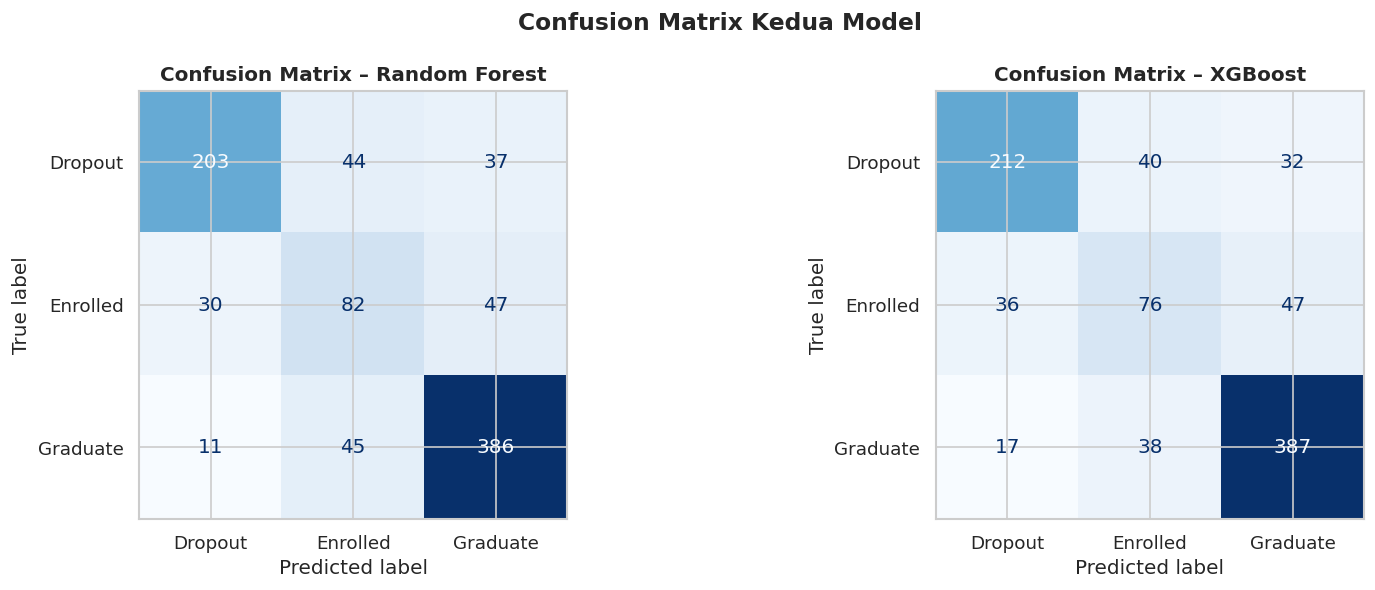

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (name, res) in zip(axes, results.items()):
    cm   = confusion_matrix(y_test, res['y_pred'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'Confusion Matrix – {name}', fontsize=12, fontweight='bold')

plt.suptitle('Confusion Matrix Kedua Model', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

Insight:
- Model XGBoost menunjukkan performa sedikit lebih baik dibanding Random Forest, dengan peningkatan prediksi benar pada kelas Dropout (212 vs 203) dan Graduate (387 vs 386), serta penurunan kesalahan klasifikasi.
- Kelas Graduate merupakan yang paling mudah diprediksi oleh kedua model (nilai diagonal tertinggi), sedangkan kelas Enrolled masih menjadi yang paling sulit dengan banyak kesalahan prediksi ke Graduate.
- Kesalahan klasifikasi terbesar terjadi pada kelas Enrolled yang sering diprediksi sebagai Graduate (47 pada kedua model), menunjukkan overlap karakteristik antara kedua kelas tersebut.

### 5. Feature Importance

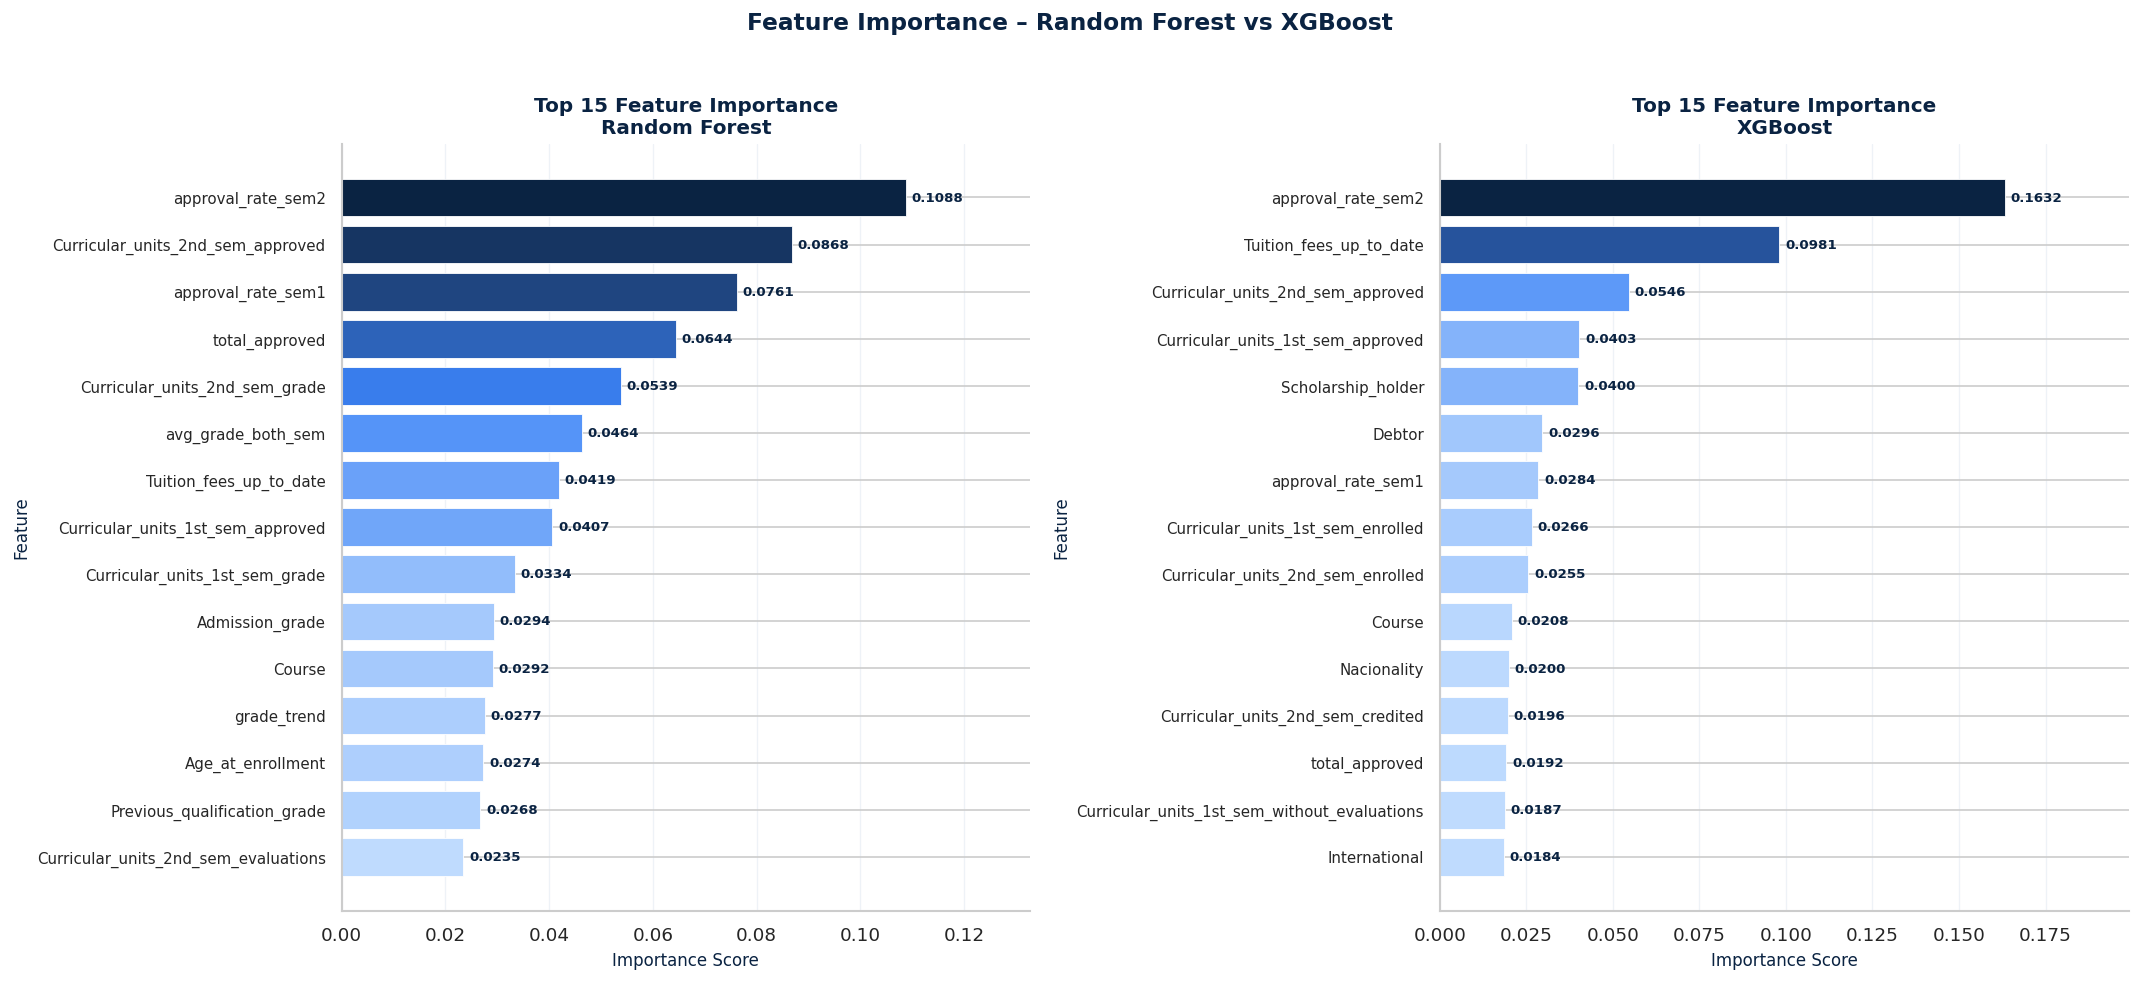


Top 10 Feature Importance – XGBoost:
   1. approval_rate_sem2                                 0.1632
   2. Tuition_fees_up_to_date                            0.0981
   3. Curricular_units_2nd_sem_approved                  0.0546
   4. Curricular_units_1st_sem_approved                  0.0403
   5. Scholarship_holder                                 0.0400
   6. Debtor                                             0.0296
   7. approval_rate_sem1                                 0.0284
   8. Curricular_units_1st_sem_enrolled                  0.0266
   9. Curricular_units_2nd_sem_enrolled                  0.0255
  10. Course                                             0.0208


In [25]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
top_n = 15

# Colormap
from matplotlib.colors import LinearSegmentedColormap
blue_importance = LinearSegmentedColormap.from_list(
    'blue_importance',
    ['#bfdbfe', '#3b82f6', '#1a3a6b', '#0a2342']
)

for ax, (name, res) in zip(axes, results.items()):
    fi_df = pd.DataFrame({'Feature': feature_cols, 'Importance': res['model'].feature_importances_})
    fi_df = fi_df.sort_values('Importance', ascending=False).head(top_n)
    fi_sorted = fi_df.sort_values('Importance', ascending=True)  # ascending untuk barh

    # Warna berdasarkan nilai importance
    norm_vals = (fi_sorted['Importance'] - fi_sorted['Importance'].min()) / \
                (fi_sorted['Importance'].max() - fi_sorted['Importance'].min())
    colors_fi = [blue_importance(v) for v in norm_vals]

    bars = ax.barh(fi_sorted['Feature'], fi_sorted['Importance'],
                   color=colors_fi, edgecolor='white', linewidth=0.5)

    # Label nilai importance di ujung bar
    for bar, val in zip(bars, fi_sorted['Importance']):
        ax.text(val + fi_sorted['Importance'].max() * 0.01,
                bar.get_y() + bar.get_height() / 2,
                f'{val:.4f}', va='center', fontsize=8,
                fontweight='600', color='#0a2342')

    ax.set_title(f'Top {top_n} Feature Importance\n{name}',
                 fontsize=12, fontweight='bold', color='#0a2342')
    ax.set_xlabel('Importance Score', fontsize=10, color='#0a2342')
    ax.set_ylabel('Feature', fontsize=10, color='#0a2342')
    ax.set_xlim(0, fi_sorted['Importance'].max() * 1.22)
    ax.spines[['top', 'right']].set_visible(False)
    ax.xaxis.grid(True, color='#eef2f7', linewidth=0.8)
    ax.set_axisbelow(True)
    ax.tick_params(axis='y', labelsize=9)

plt.suptitle('Feature Importance – Random Forest vs XGBoost',
             fontsize=14, fontweight='bold', color='#0a2342', y=1.02)
plt.tight_layout()
plt.show()

best_fi = pd.DataFrame({'Feature': feature_cols, 'Importance': best_model.feature_importances_})
best_fi = best_fi.sort_values('Importance', ascending=False)

print(f'\nTop 10 Feature Importance – {best_model_name}:')
for rank, (_, row) in enumerate(best_fi.head(10).iterrows(), 1):
    print(f'  {rank:2d}. {row["Feature"]:<50} {row["Importance"]:.4f}')

### 6. Cross-Validation Score

In [26]:
print(f'=== CROSS VALIDATION (5-Fold Stratified) – {best_model_name} ===')
cv_scores = cross_val_score(
    best_model, X_train_smote, y_train_smote,
    cv=cv_strat, scoring='f1_weighted', n_jobs=-1
)
print(f'CV F1-Score per fold : {[f"{s:.4f}" for s in cv_scores]}')
print(f'Mean CV F1-Score     : {cv_scores.mean():.4f}')
print(f'Std CV F1-Score      : {cv_scores.std():.4f}')
print(f'\nModel menunjukkan performa yang stabil dan konsisten lintas fold.')

=== CROSS VALIDATION (5-Fold Stratified) – XGBoost ===
CV F1-Score per fold : ['0.8428', '0.8680', '0.8391', '0.8746', '0.8737']
Mean CV F1-Score     : 0.8596
Std CV F1-Score      : 0.0154

Model menunjukkan performa yang stabil dan konsisten lintas fold.


### 7. Simpan Model dan Artefak

In [27]:
os.makedirs('model', exist_ok=True)

joblib.dump(best_model,   'model/model.pkl')
joblib.dump(le,           'model/label_encoder.pkl')
joblib.dump(feature_cols, 'model/feature_cols.pkl')

print(f'Model ({best_model_name}) disimpan  -> model/model.pkl')
print(f'Label encoder disimpan             -> model/label_encoder.pkl')
print(f'Feature columns disimpan           -> model/feature_cols.pkl')

Model (XGBoost) disimpan  -> model/model.pkl
Label encoder disimpan             -> model/label_encoder.pkl
Feature columns disimpan           -> model/feature_cols.pkl


### 8. Ringkasan Akhir

In [28]:
print('=' * 65)
print('         RINGKASAN HASIL PROYEK MACHINE LEARNING')
print('=' * 65)
print(f'  Dataset          : Jaya Jaya Institut – Student Performance')
print(f'  Total Sampel     : {len(df):,}')
print(f'  Total Fitur      : {len(feature_cols)} (termasuk {len(new_features)} fitur hasil engineering)')
print(f'  Teknik Imbalance : SMOTE (k_neighbors=5, hanya pada training set)')
print(f'  Tuning           : RandomizedSearchCV (50 iterasi, 5-Fold Stratified CV)')
print(f'  Model Terbaik    : {best_model_name}')
print(f'  Accuracy         : {results[best_model_name]["Accuracy"]:.4f}')
print(f'  F1-Score         : {results[best_model_name]["F1-Score"]:.4f}')
print(f'  Precision        : {results[best_model_name]["Precision"]:.4f}')
print(f'  Recall           : {results[best_model_name]["Recall"]:.4f}')
print('=' * 65)
print('\nTop 5 Fitur Terpenting:')
for rank, (_, row) in enumerate(best_fi.head(5).iterrows(), 1):
    print(f'  {rank}. {row["Feature"]}')
print('\nSemua artefak model telah disimpan di folder model/')

         RINGKASAN HASIL PROYEK MACHINE LEARNING
  Dataset          : Jaya Jaya Institut – Student Performance
  Total Sampel     : 4,424
  Total Fitur      : 42 (termasuk 6 fitur hasil engineering)
  Teknik Imbalance : SMOTE (k_neighbors=5, hanya pada training set)
  Tuning           : RandomizedSearchCV (50 iterasi, 5-Fold Stratified CV)
  Model Terbaik    : XGBoost
  Accuracy         : 0.7627
  F1-Score         : 0.7608
  Precision        : 0.7602
  Recall           : 0.7627

Top 5 Fitur Terpenting:
  1. approval_rate_sem2
  2. Tuition_fees_up_to_date
  3. Curricular_units_2nd_sem_approved
  4. Curricular_units_1st_sem_approved
  5. Scholarship_holder

Semua artefak model telah disimpan di folder model/
